In [57]:
# ============================================================
# Shopper Spectrum
# Customer Segmentation & Product Recommendation
# Author : Anamey Deorukhkar
# ============================================================

# ----------------------------
# Data Manipulation
# ----------------------------
import pandas as pd
import numpy as np

# ----------------------------
# Data Visualization
# ----------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# Machine Learning
# ----------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

# ----------------------------
# Model Saving
# ----------------------------
import joblib
import os
# ----------------------------
# Utilities
# ----------------------------
import warnings
warnings.filterwarnings("ignore")

# ----------------------------
# Plot Styling
# ----------------------------
sns.set_theme(style="whitegrid", context="talk")

plt.rcParams["figure.figsize"] = (12,6)
plt.rcParams["figure.dpi"] = 150
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11

In [2]:
df = pd.read_csv(r"C:\Users\Anamey\Downloads\online_retail.csv")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
print("Shape:", df.shape)
print("----------------------------------------------------")
df.info()
print("----------------------------------------------------")
df.describe()
print("----------------------------------------------------")
df.sample(5)

Shape: (541909, 8)
----------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
----------------------------------------------------
----------------------------------------------------


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
74932,542536,22382,LUNCH BAG SPACEBOY DESIGN,2,2023-01-28 13:37:00,4.13,NaN,United Kingdom
493318,578225,23318,BOX OF 6 MINI VINTAGE CRACKERS,6,2023-11-23 11:51:00,2.49,17700.0,United Kingdom
420076,572872,22429,ENAMEL MEASURING JUG CREAM,1,2023-10-26 13:27:00,4.25,15320.0,United Kingdom
222563,556433,23298,SPOTTY BUNTING,8,2023-06-10 14:01:00,10.79,NaN,United Kingdom
405343,571713,23382,BOX OF 6 CHRISTMAS CAKE DECORATIONS,1,2023-10-18 16:58:00,7.46,NaN,United Kingdom


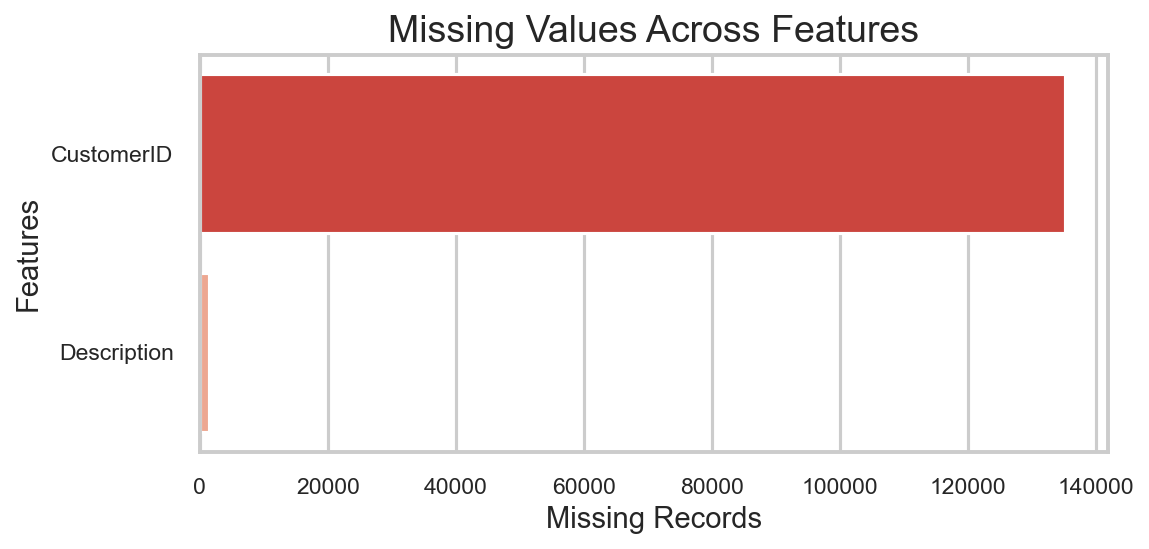

In [4]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing = missing[missing > 0]

plt.figure(figsize=(8,4))

sns.barplot(
    x=missing.values,
    y=missing.index,
    palette="Reds_r"
)

plt.title("Missing Values Across Features")

plt.xlabel("Missing Records")

plt.ylabel("Features")

plt.tight_layout()

plt.show()

In [5]:
# Create a copy of the original dataset
retail = df.copy()

duplicate_count = retail.duplicated().sum()

print("Duplicate Records:", duplicate_count)

Duplicate Records: 5268


In [6]:
retail.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", retail.shape)

Shape after removing duplicates: (536641, 8)


In [7]:
print("Before:", retail.shape)

retail = retail.dropna(subset=["CustomerID"])

print("After:", retail.shape)

Before: (536641, 8)
After: (401604, 8)


In [8]:
retail = retail[
    ~retail["InvoiceNo"].astype(str).str.startswith("C")
]

In [9]:
retail = retail[retail["Quantity"] > 0]

retail = retail[retail["UnitPrice"] > 0]

In [10]:
print(retail.shape)
print("---------------------------------------------------------")
retail.head()
print("---------------------------------------------------------")
retail.info()

(392692, 8)
---------------------------------------------------------
---------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    392692 non-null  object 
 1   StockCode    392692 non-null  object 
 2   Description  392692 non-null  object 
 3   Quantity     392692 non-null  int64  
 4   InvoiceDate  392692 non-null  object 
 5   UnitPrice    392692 non-null  float64
 6   CustomerID   392692 non-null  float64
 7   Country      392692 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.0+ MB


In [11]:
retail = retail.assign(
    TotalAmount = retail["Quantity"] * retail["UnitPrice"]
)

In [12]:
retail["InvoiceDate"] = pd.to_datetime(
    retail["InvoiceDate"]
)

In [13]:
retail.head()
print("----------------------------------------------------")
retail.info()
print("----------------------------------------------------")
retail.describe()

----------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
 8   TotalAmount  392692 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.0+ MB
----------------------------------------------------


,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalAmount
count,392692.000000,392692,392692.000000,392692.000000,392692.000000
mean,13.119702,2023-07-10 19:13:07.771892224,3.125914,15287.843865,22.631500
min,1.000000,2022-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2023-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,6.000000,2023-07-31 12:02:00,1.950000,15150.000000,12.450000
75%,12.000000,2023-10-20 12:53:00,3.750000,16791.000000,19.800000
max,80995.000000,2023-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.492832,NaN,22.241836,1713.539549,311.099224


In [14]:
country_transactions = (
    retail.groupby("Country")["InvoiceNo"]
          .count()
          .sort_values(ascending=False)
)

country_transactions.head(10)

Country
United Kingdom    349203
Germany             9025
France              8326
EIRE                7226
Spain               2479
Netherlands         2359
Belgium             2031
Switzerland         1841
Portugal            1453
Australia           1181
Name: InvoiceNo, dtype: int64

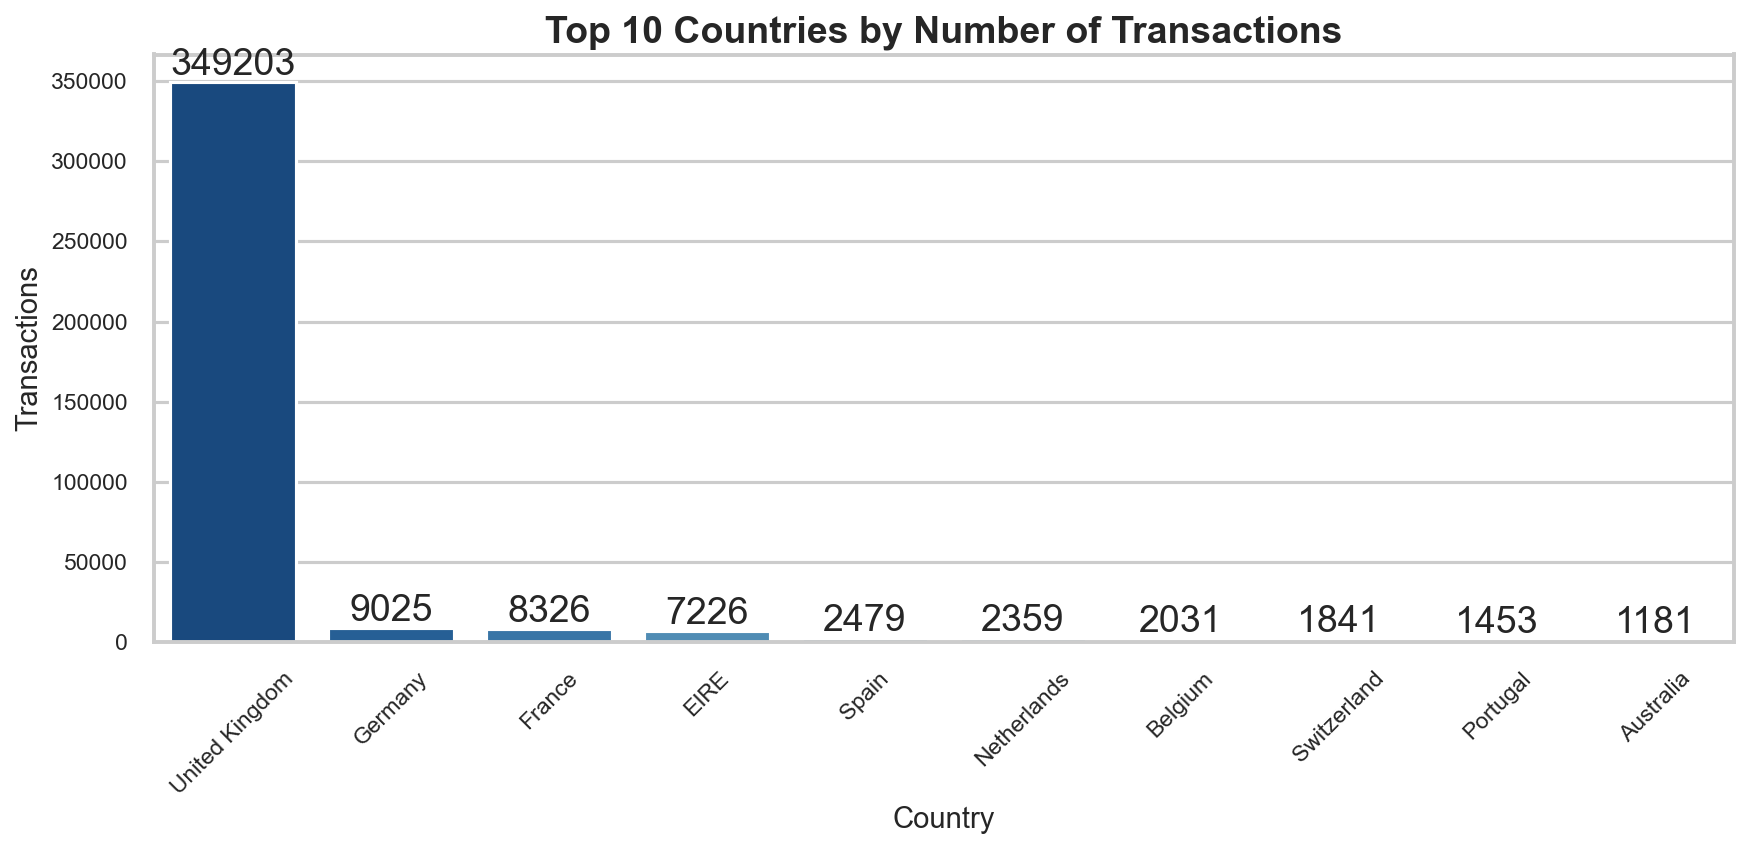

In [15]:
top10 = country_transactions.head(10)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top10.index,
    y=top10.values,
    palette="Blues_r"
)

plt.title(
    "Top 10 Countries by Number of Transactions",
    weight="bold"
)

plt.xlabel("Country")

plt.ylabel("Transactions")

plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()

plt.show()

In [16]:
top_products = (
    retail.groupby("Description")["Quantity"]
          .sum()
          .sort_values(ascending=False)
)

top_products.head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

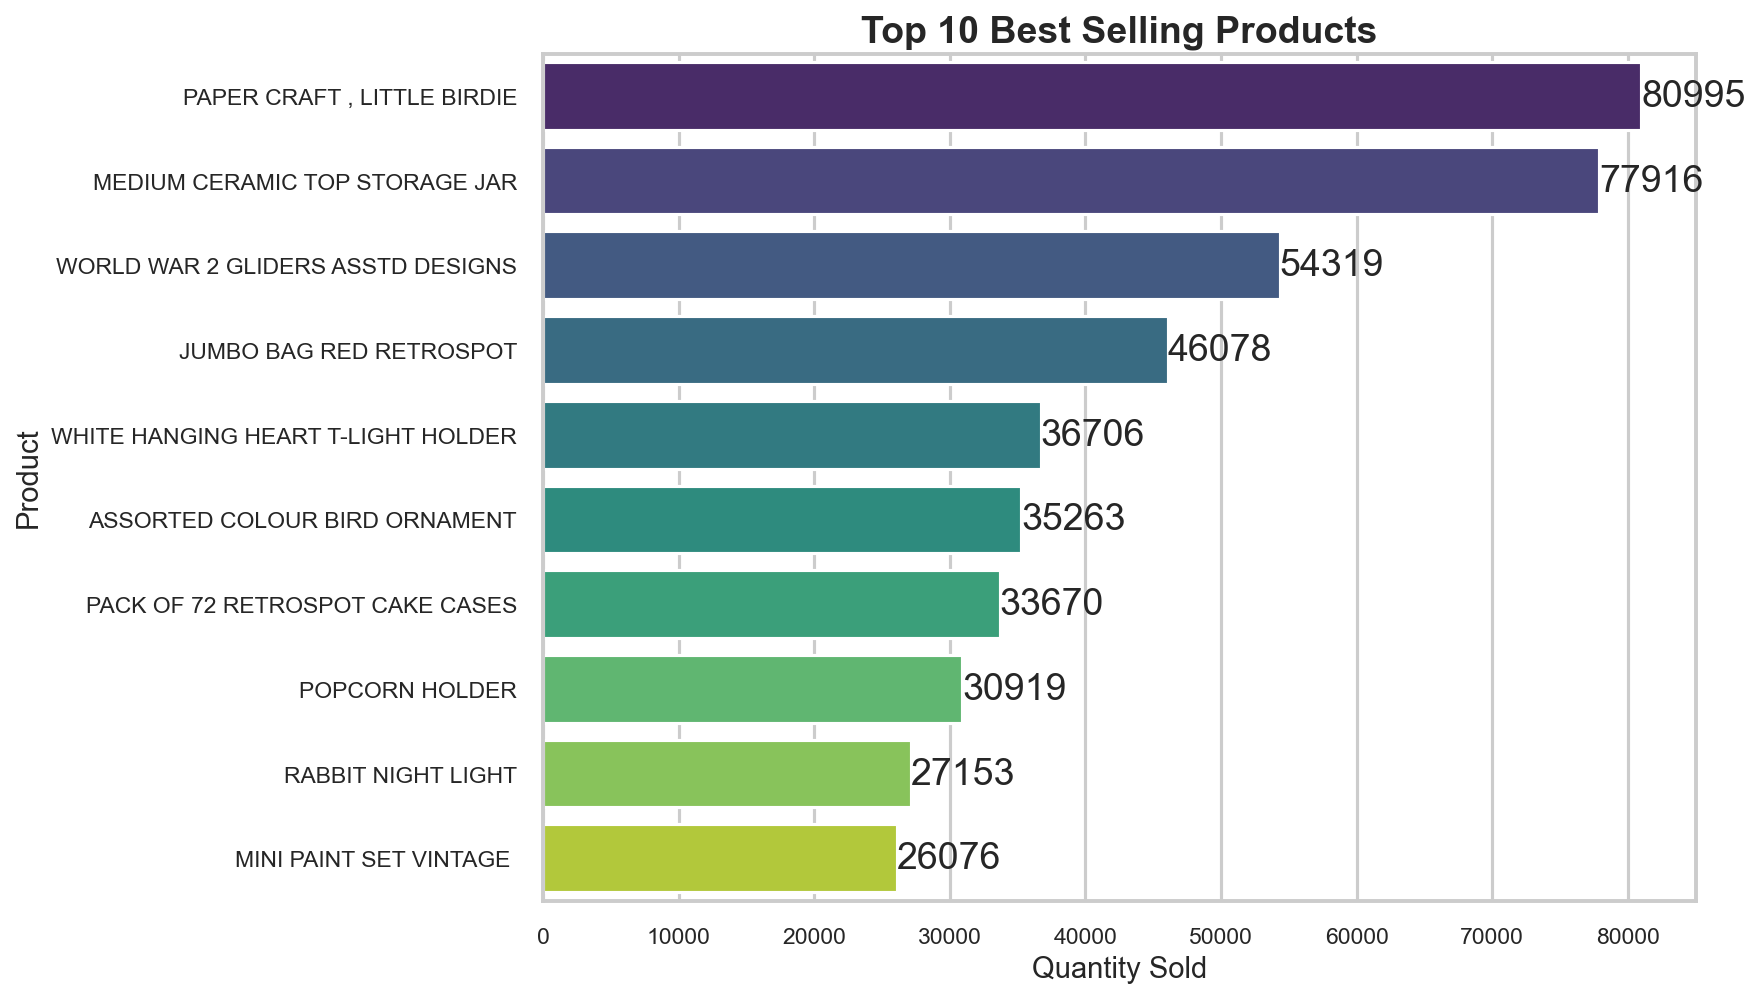

In [17]:
plt.figure(figsize=(12,7))

ax = sns.barplot(
    x=top_products.head(10).values,
    y=top_products.head(10).index,
    palette="viridis"
)

plt.title(
    "Top 10 Best Selling Products",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Quantity Sold")

plt.ylabel("Product")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()

plt.show()

In [18]:
retail["Month"] = retail["InvoiceDate"].dt.to_period("M")
monthly_sales = (
    retail.groupby("Month")["TotalAmount"]
    .sum()/100000
)

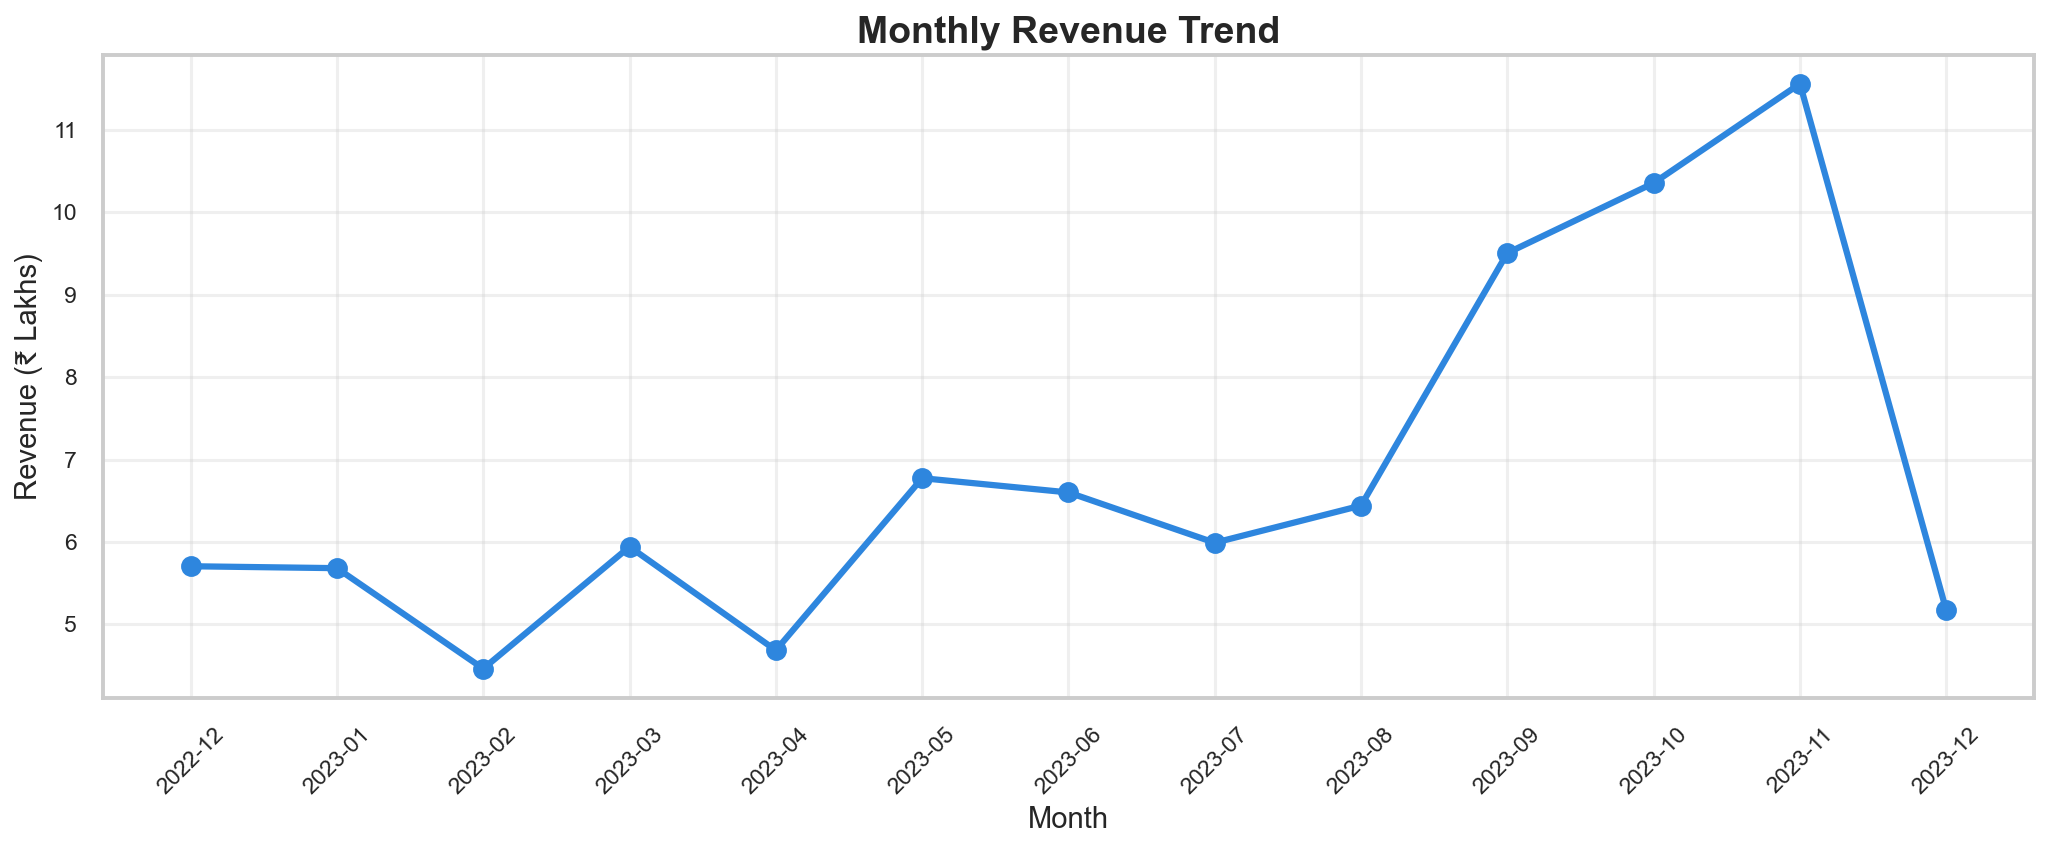

In [19]:
monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    linewidth=3,
    color="#2E86DE"
)

plt.title(
    "Monthly Revenue Trend",
    fontsize=18,
    weight="bold"
)

plt.ylabel("Revenue (₹ Lakhs)")
plt.xlabel("Month")

plt.xticks(rotation=45)

plt.grid(alpha=.3)

plt.tight_layout()

plt.show()

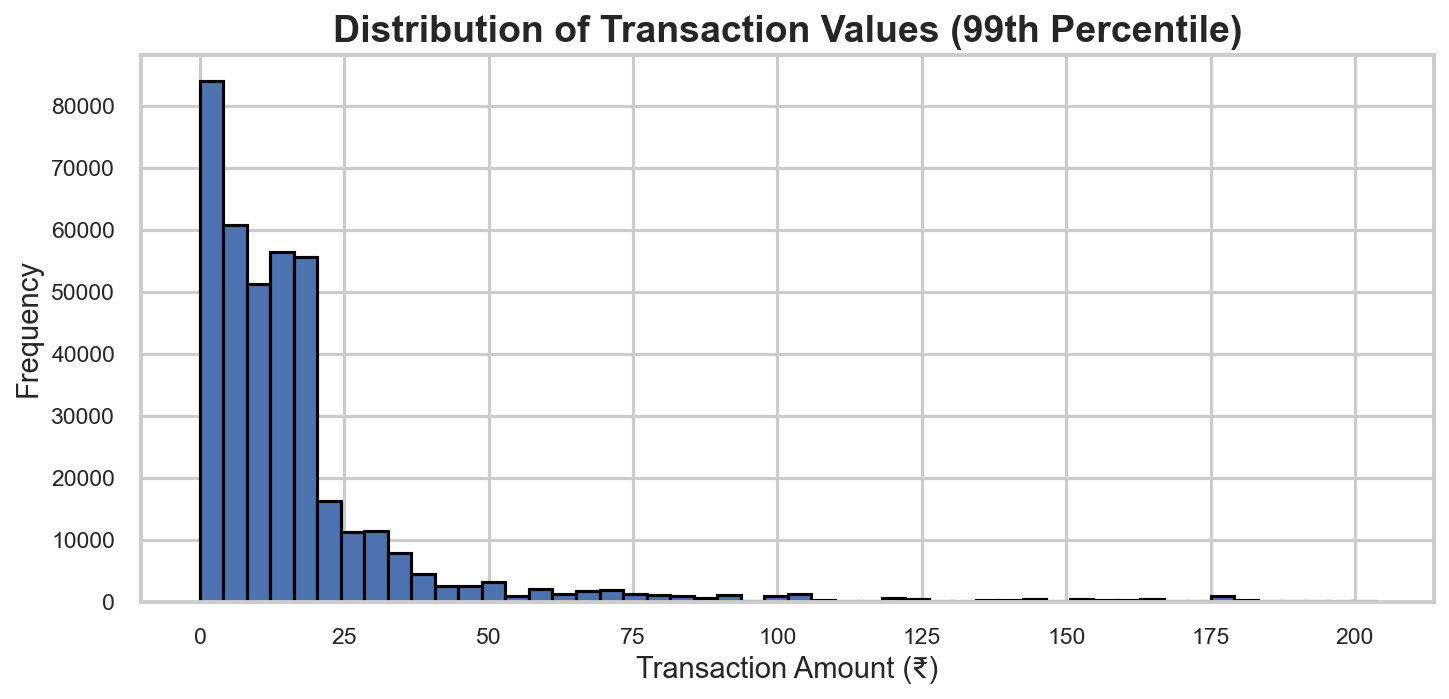

In [20]:
q99 = retail["TotalAmount"].quantile(0.99)

plt.figure(figsize=(10,5))

plt.hist(
    retail.loc[
        retail["TotalAmount"] <= q99,
        "TotalAmount"
    ],
    bins=50,
    edgecolor="black"
)

plt.title(
    "Distribution of Transaction Values (99th Percentile)",
    weight="bold"
)

plt.xlabel("Transaction Amount (₹)")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

In [21]:
print("="*60)

print("DATASET SUMMARY")

print("="*60)

print(f"Transactions : {len(retail):,}")

print(f"Customers    : {retail['CustomerID'].nunique():,}")

print(f"Products     : {retail['Description'].nunique():,}")

print(f"Countries    : {retail['Country'].nunique()}")

print("="*60)

DATASET SUMMARY
Transactions : 392,692
Customers    : 4,338
Products     : 3,877
Countries    : 37


In [22]:
snapshot_date = retail["InvoiceDate"].max() + pd.Timedelta(days=1)

print(f"Snapshot Date : {snapshot_date}")

Snapshot Date : 2023-12-10 12:50:00


In [23]:
rfm = (
    retail
    .groupby("CustomerID")
    .agg(
        Recency=(
            "InvoiceDate",
            lambda x: (snapshot_date - x.max()).days
        ),

        Frequency=(
            "InvoiceNo",
            "nunique"
        ),

        Monetary=(
            "TotalAmount",
            "sum"
        )
    )
    .reset_index()
)

In [24]:
print("=" * 60)
print("RFM DATASET")
print("=" * 60)

print(f"Customers : {len(rfm):,}")

display(rfm.head())

display(rfm.describe())

RFM DATASET
Customers : 4,338


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


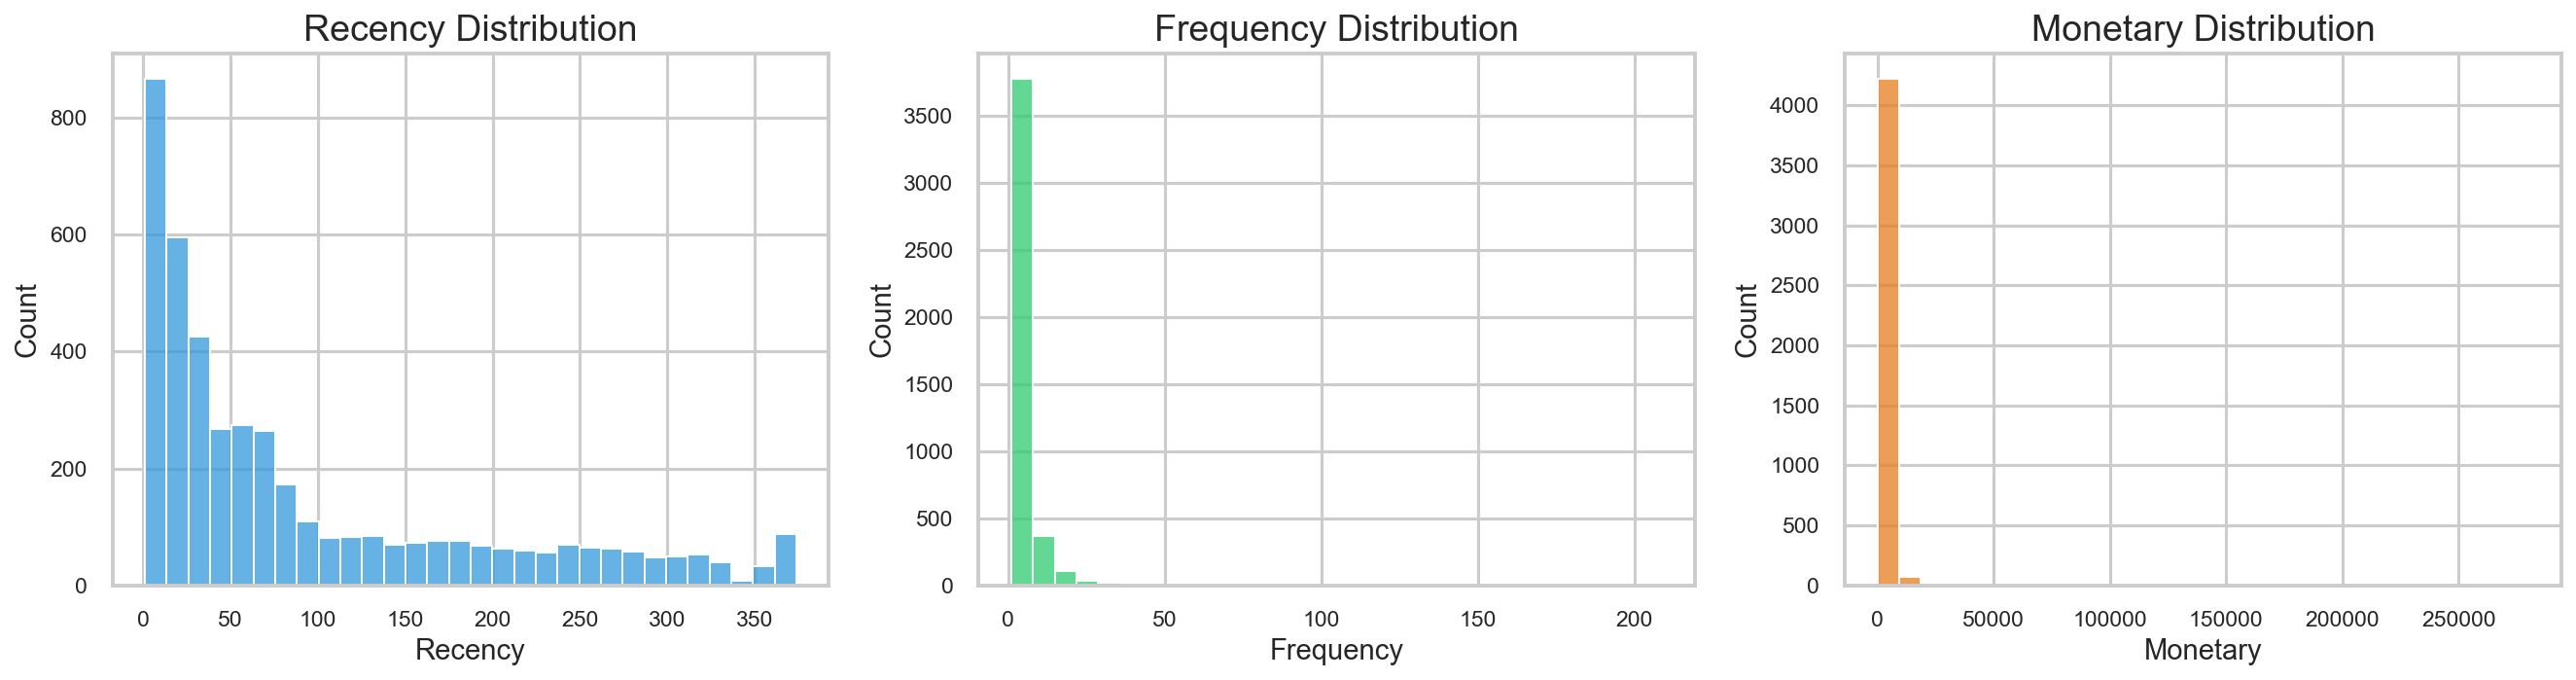

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm["Recency"], bins=30, ax=axes[0], color="#3498DB")
axes[0].set_title("Recency Distribution")

sns.histplot(rfm["Frequency"], bins=30, ax=axes[1], color="#2ECC71")
axes[1].set_title("Frequency Distribution")

sns.histplot(rfm["Monetary"], bins=30, ax=axes[2], color="#E67E22")
axes[2].set_title("Monetary Distribution")

plt.tight_layout()
plt.show()

In [26]:
rfm_features = rfm[["Recency", "Frequency", "Monetary"]]

rfm_features.head()

,Recency,Frequency,Monetary
0,326,1,77183.60
1,2,7,4310.00
2,75,4,1797.24
3,19,1,1757.55
4,310,1,334.40


In [27]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_features)

In [28]:
scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=rfm_features.columns
)

scaled_df.describe().round(2)

,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00
mean,0.00,0.00,0.00
std,1.00,1.00,1.00
min,-0.92,-0.43,-0.23
25%,-0.75,-0.43,-0.19
50%,-0.42,-0.30,-0.15
75%,0.49,0.09,-0.04
max,2.81,26.60,30.96


In [29]:
inertia = []

k_range = range(2, 11)

for k in k_range:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(rfm_scaled)

    inertia.append(model.inertia_)

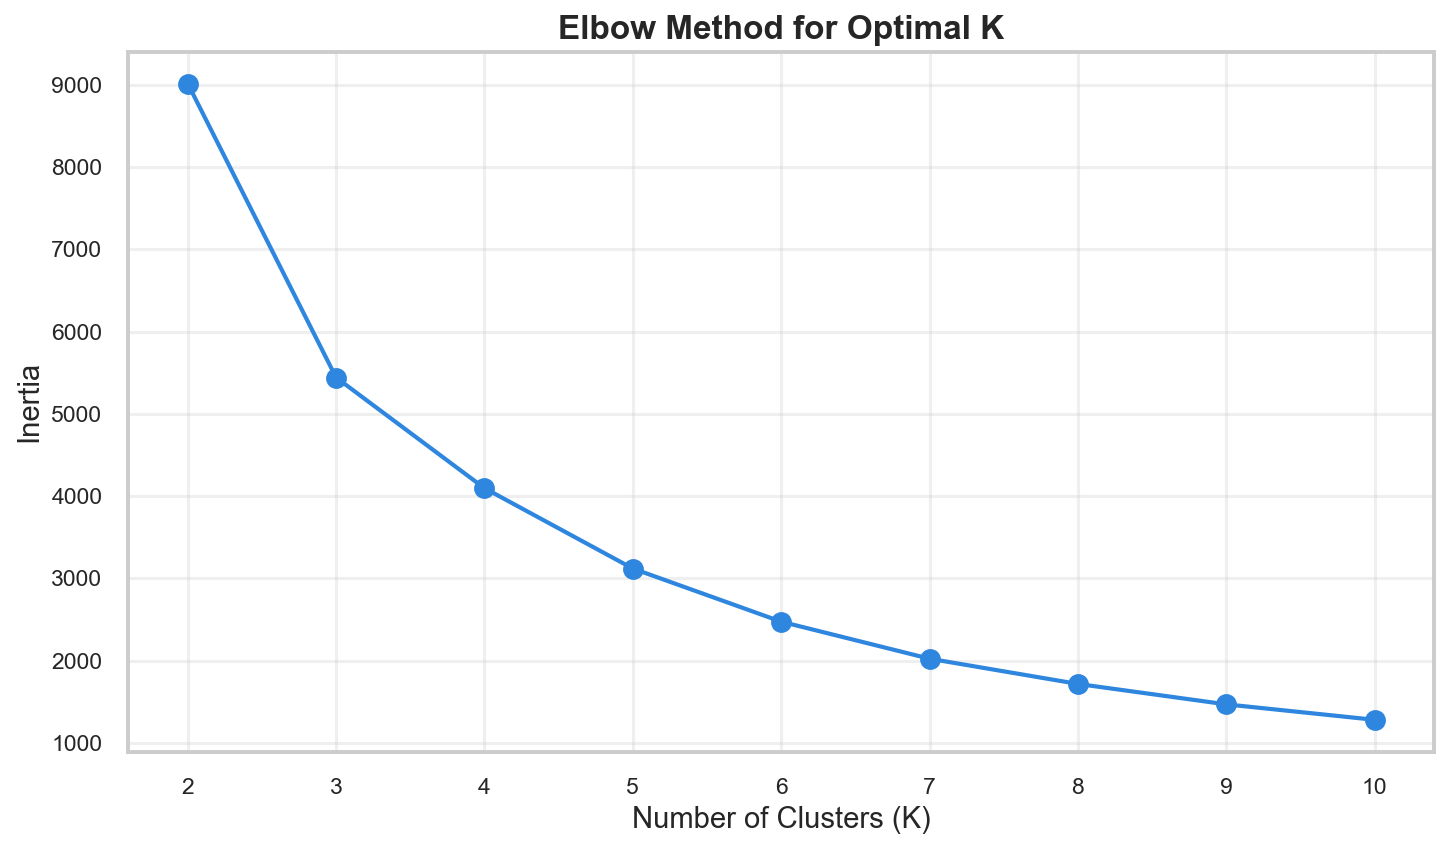

In [30]:
plt.figure(figsize=(10,6))

plt.plot(
    k_range,
    inertia,
    marker="o",
    linewidth=2,
    color="#2E86DE"
)

plt.title(
    "Elbow Method for Optimal K",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Number of Clusters (K)")

plt.ylabel("Inertia")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [31]:
silhouette_scores = []

for k in k_range:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(rfm_scaled)

    score = silhouette_score(rfm_scaled, labels)

    silhouette_scores.append(score)

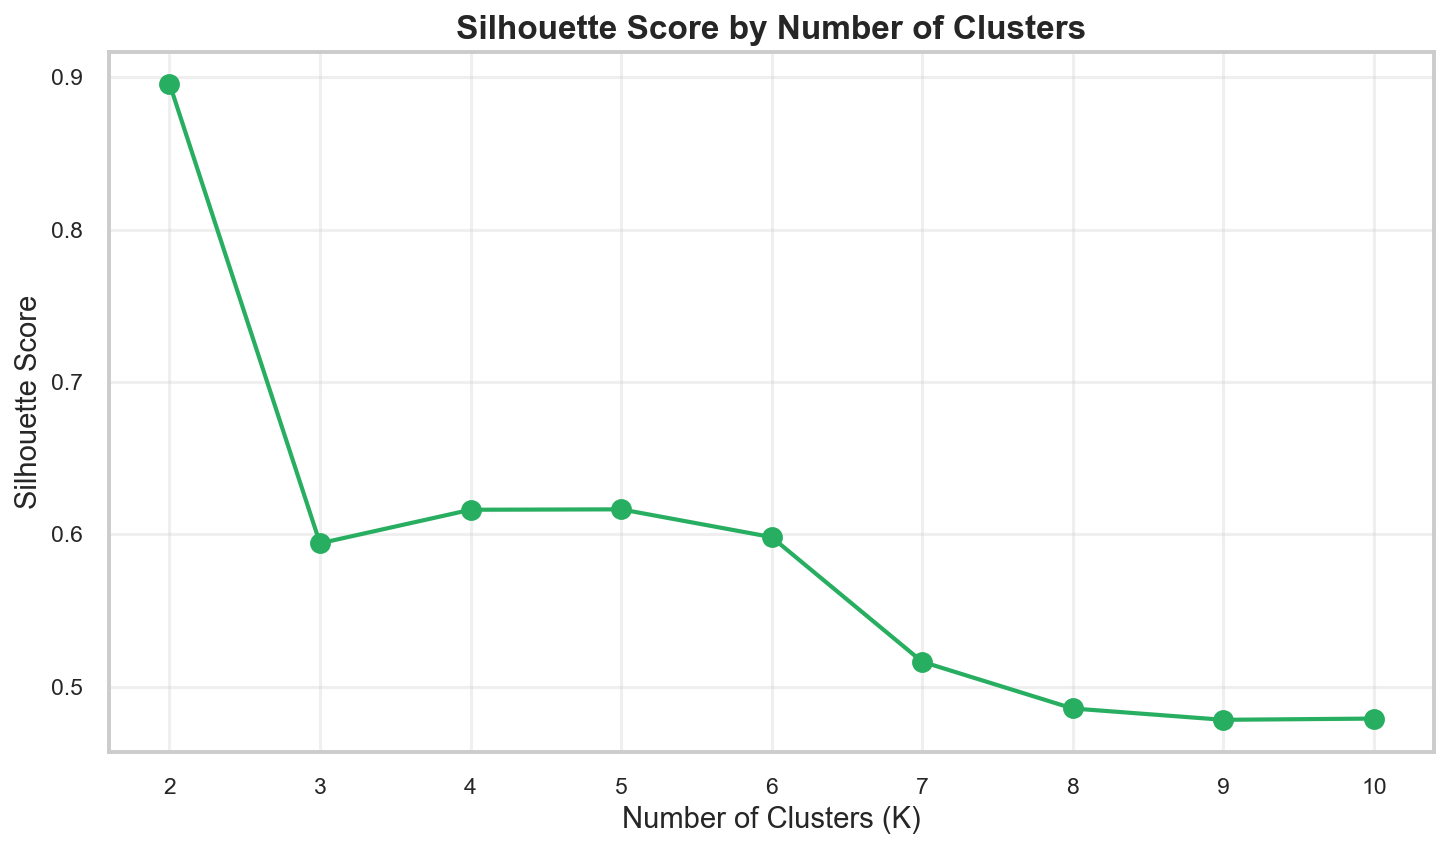

In [32]:
plt.figure(figsize=(10,6))

plt.plot(
    k_range,
    silhouette_scores,
    marker="o",
    linewidth=2,
    color="#27AE60"
)

plt.title(
    "Silhouette Score by Number of Clusters",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Number of Clusters (K)")

plt.ylabel("Silhouette Score")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [33]:
# ============================================================
# Final KMeans Model
# ============================================================

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(rfm_scaled)

In [34]:
rfm["Cluster"] = clusters

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,3
1,12347.0,2,7,4310.00,0
2,12348.0,75,4,1797.24,0
3,12349.0,19,1,1757.55,0
4,12350.0,310,1,334.40,1


In [35]:
cluster_sizes = (
    rfm["Cluster"]
    .value_counts()
    .sort_index()
)

display(cluster_sizes)

Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64

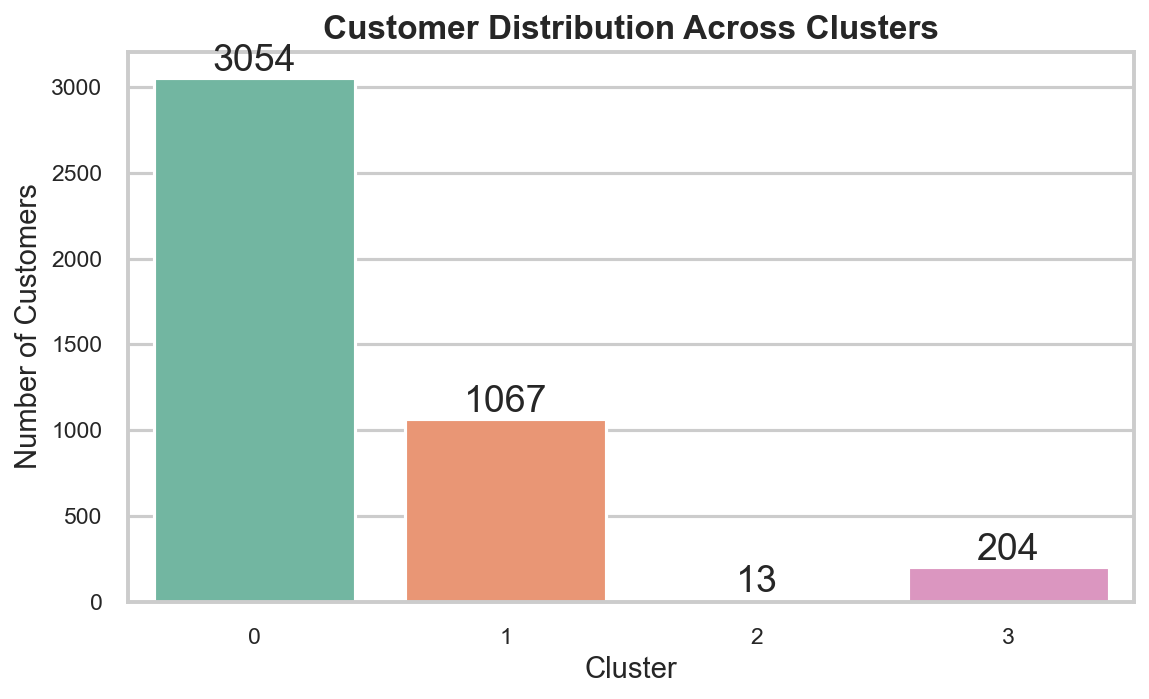

In [36]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=rfm,
    x="Cluster",
    palette="Set2"
)

plt.title(
    "Customer Distribution Across Clusters",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Cluster")

plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()

plt.show()

In [37]:
cluster_profile = (
    rfm
    .groupby("Cluster")
    [["Recency","Frequency","Monetary"]]
    .mean()
    .round(2)
)

display(cluster_profile)

,Recency,Frequency,Monetary
Cluster,,,
0,43.70,3.68,1353.63
1,248.08,1.55,478.85
2,7.38,82.54,127187.96
3,15.50,22.33,12690.50


In [38]:
cluster_labels = {
    0: "Occasional",
    1: "At-Risk",
    2: "High-Value",
    3: "Regular"
}

rfm["Segment"] = rfm["Cluster"].map(cluster_labels)

In [39]:
segment_summary = (
    rfm["Segment"]
    .value_counts()
    .reset_index()
)

segment_summary.columns = ["Segment","Customers"]

display(segment_summary)

,Segment,Customers
0,Occasional,3054
1,At-Risk,1067
2,Regular,204
3,High-Value,13


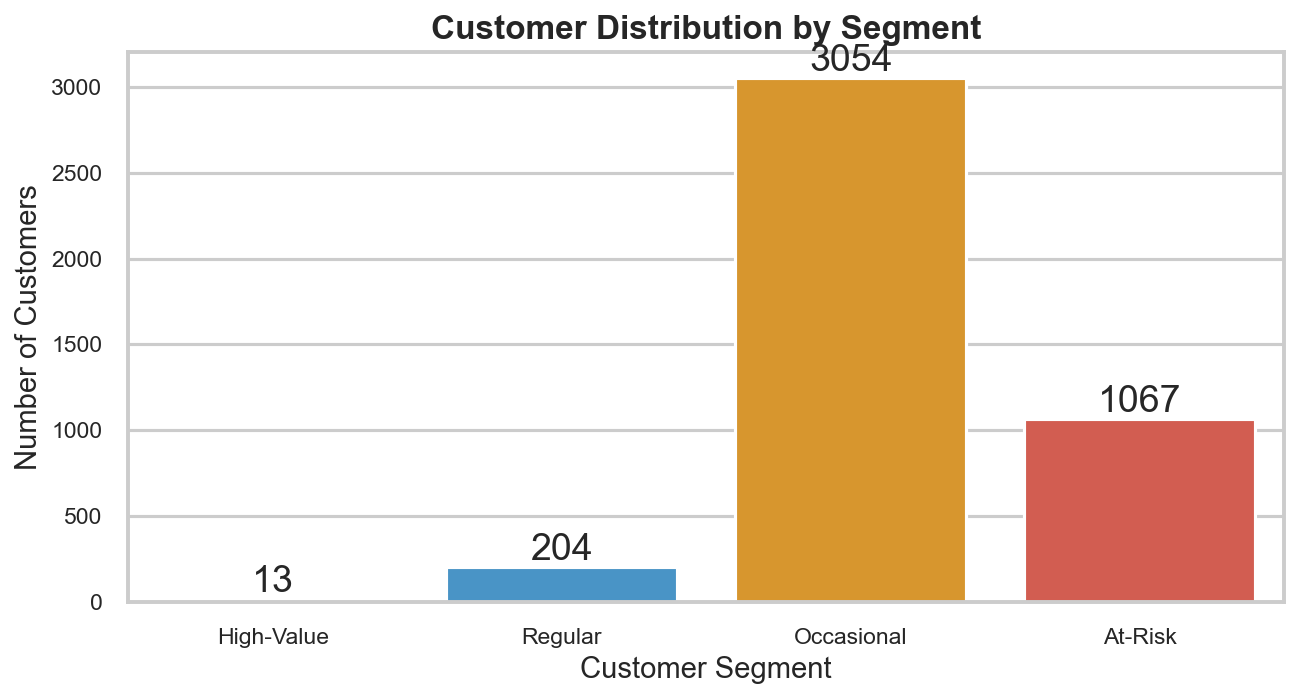

In [40]:
plt.figure(figsize=(9,5))

ax = sns.countplot(
    data=rfm,
    x="Segment",
    order=[
        "High-Value",
        "Regular",
        "Occasional",
        "At-Risk"
    ],
    palette=["#2ECC71","#3498DB","#F39C12","#E74C3C"]
)

plt.title(
    "Customer Distribution by Segment",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [41]:
pca = PCA(n_components=2)

rfm_pca = pca.fit_transform(rfm_scaled)

In [42]:
pca_df = pd.DataFrame(
    rfm_pca,
    columns=["PC1","PC2"]
)

pca_df["Segment"] = rfm["Segment"]

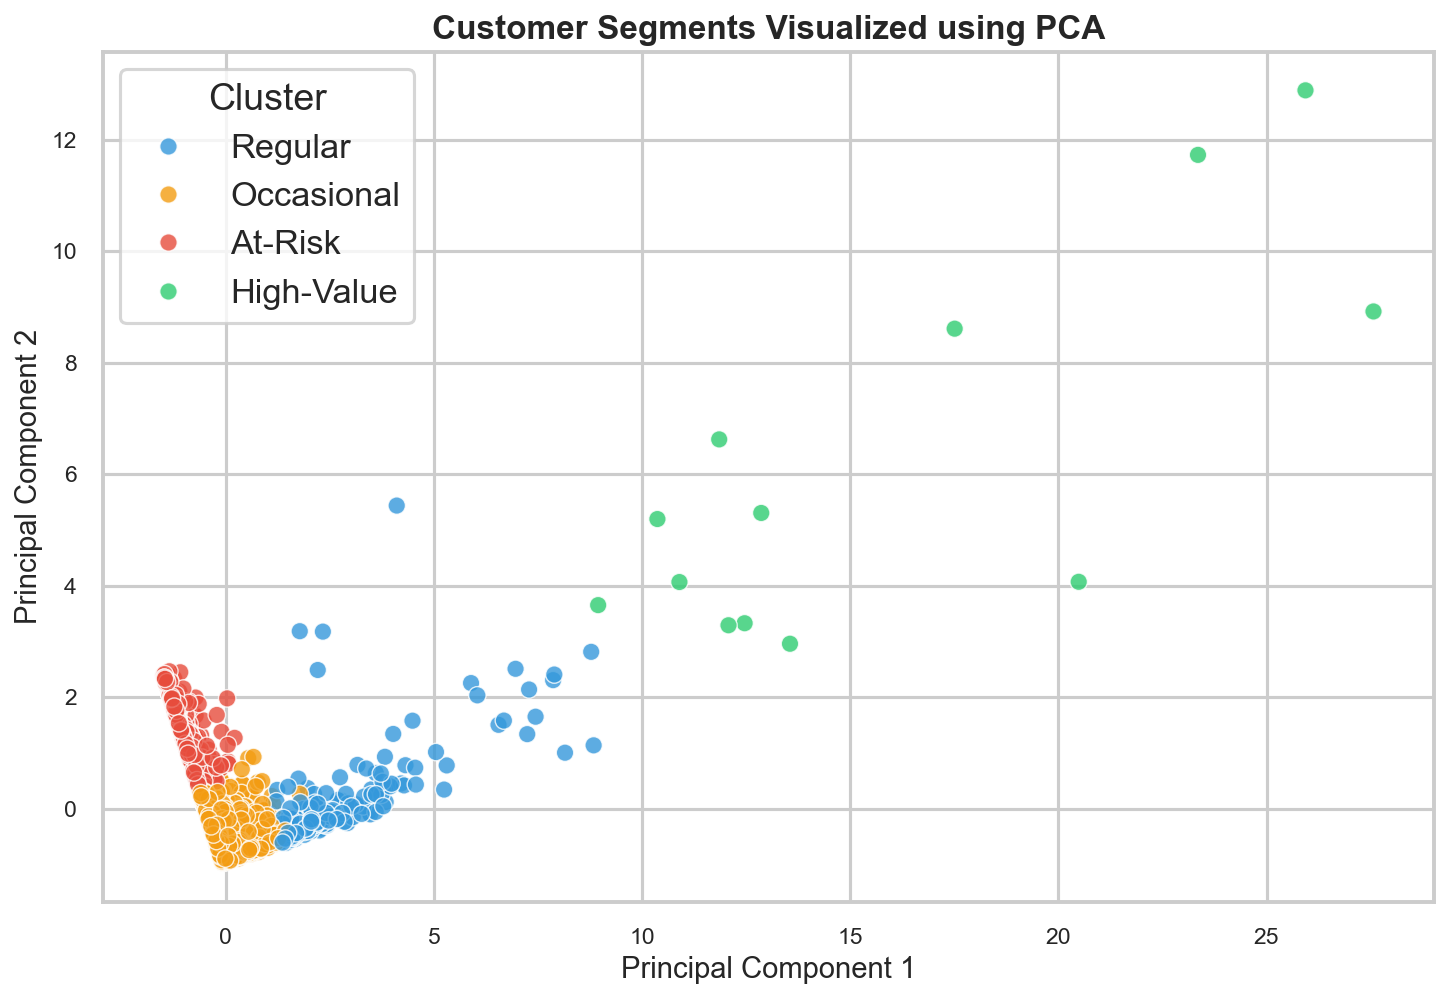

In [43]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Segment",
    palette={
        "High-Value": "#2ECC71",
        "Regular": "#3498DB",
        "Occasional": "#F39C12",
        "At-Risk": "#E74C3C"
    },
    s=70,
    alpha=0.8
)

plt.title(
    "Customer Segments Visualized using PCA",
    fontsize=16,
    weight="bold"
)

plt.legend(title="Cluster")

plt.tight_layout()
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [44]:
centroids = (
    pca_df
    .groupby("Segment")[["PC1", "PC2"]]
    .mean()
    .reset_index()
)

display(centroids)

,Segment,PC1,PC2
0,At-Risk,-0.941228,1.290268
1,High-Value,15.989547,6.204764
2,Occasional,0.085371,-0.483306
3,Regular,2.625989,0.091369


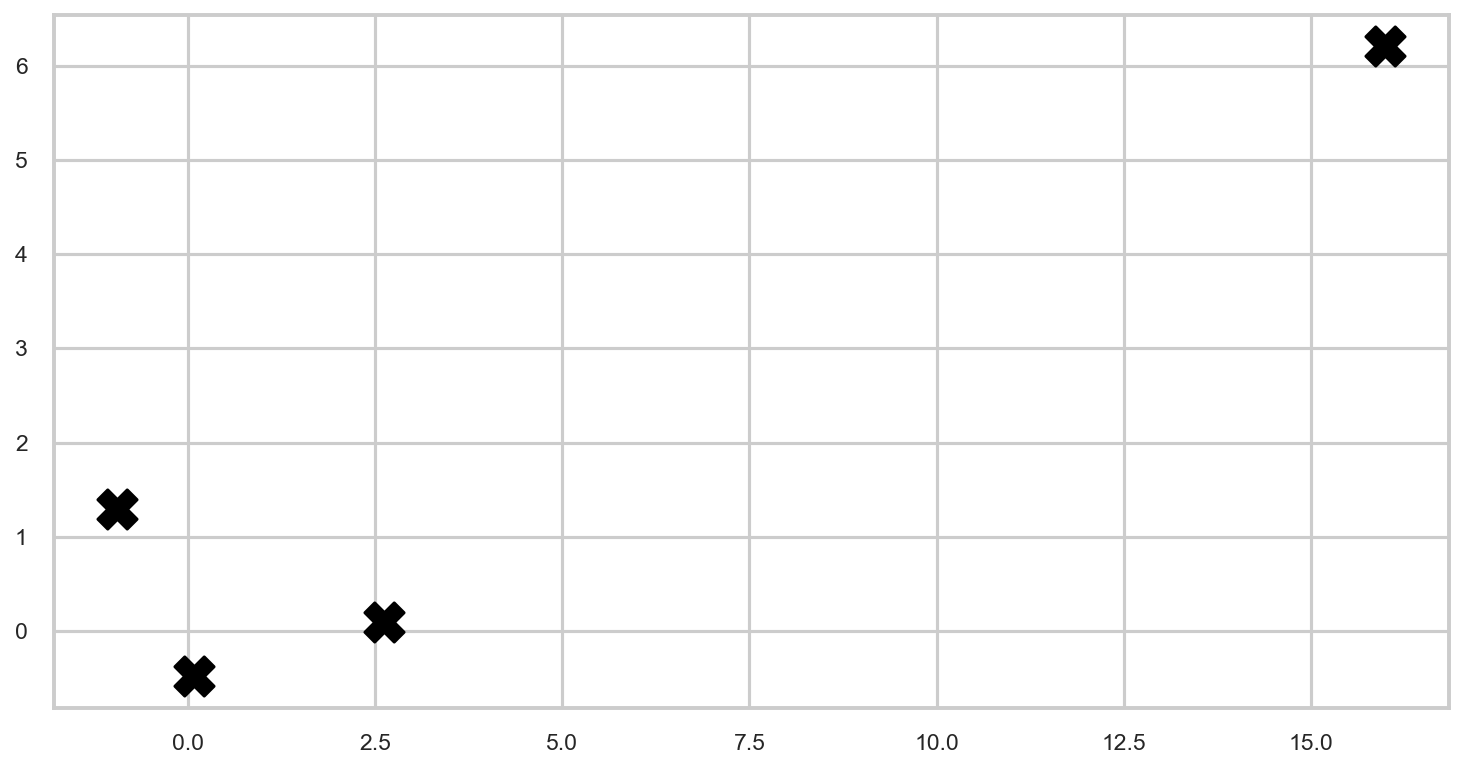

In [45]:
plt.scatter(
    centroids["PC1"],
    centroids["PC2"],
    marker="X",
    s=350,
    color="black",
    label="Centroid"
)

In [46]:
joblib.dump(kmeans, "models/kmeans_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")

FileNotFoundError: [Errno 2] No such file or directory: 'models/kmeans_model.pkl'

In [48]:
customer_product_matrix = retail.pivot_table(
    index="CustomerID",
    columns="Description",
    values="Quantity",
    aggfunc="sum",
    fill_value=0
)

In [49]:
print(customer_product_matrix.shape)

customer_product_matrix.iloc[:5, :5]

(4338, 3877)


Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK
CustomerID,,,,,
12346.0,0,0,0,0,0
12347.0,0,0,0,0,0
12348.0,0,0,0,0,0
12349.0,0,0,0,0,0
12350.0,0,0,0,0,0


In [50]:
product_similarity = cosine_similarity(
    customer_product_matrix.T
)

In [53]:
similarity_df = pd.DataFrame(
    product_similarity,
    index=customer_product_matrix.columns,
    columns=customer_product_matrix.columns
)


In [54]:
def recommend_products(product_name, top_n=5):
    """
    Recommend products similar to the selected product.
    """

    if product_name not in similarity_df.index:
        return "Product not found."

    recommendations = (
        similarity_df[product_name]
        .sort_values(ascending=False)
        .iloc[1:top_n+1]
    )

    return recommendations

In [55]:
recommend_products(
    "WHITE HANGING HEART T-LIGHT HOLDER"
)

Description
GIN + TONIC DIET METAL SIGN         0.750192
RED HANGING HEART T-LIGHT HOLDER    0.658714
WASHROOM METAL SIGN                 0.643520
LAUNDRY 15C METAL SIGN              0.642200
GREEN VINTAGE SPOT BEAKER           0.631463
Name: WHITE HANGING HEART T-LIGHT HOLDER, dtype: float64

In [66]:
import os

MODEL_DIR = "models"

os.makedirs(MODEL_DIR, exist_ok=True)

In [67]:
joblib.dump(
    kmeans,
    os.path.join(MODEL_DIR, "kmeans_model.pkl")
)

joblib.dump(
    scaler,
    os.path.join(MODEL_DIR, "scaler.pkl")
)

joblib.dump(
    customer_product_matrix.columns.tolist(),
    os.path.join(MODEL_DIR, "product_names.pkl")
)

['models\\product_names.pkl']

In [69]:
# Create data folder if it doesn't exist
import os

os.makedirs("data", exist_ok=True)

# Save cleaned dataset
retail.to_csv(
    "data/Online Retail.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!
